5-3강

# 다중분류 (CIFAR10 데이터셋)

https://youtu.be/etAJq_RsmK0?si=Sp2nbvOhpC3upuub

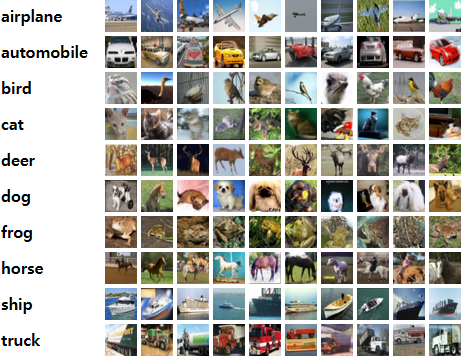

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
import sys
sys.path.append('/content/drive/MyDrive/대학원/pytorch/hyukppen/')
from multiclass_functions1 import * # * 은 all을 의미
import torch
from torch import nn, optim
from torchvision import datasets, transforms
import numpy as np
import matplotlib.pyplot as plt
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(DEVICE)

Mounted at /content/drive
cuda


In [ ]:
new_model_train = True # 모델 새로 만들거면 True

In [ ]:
# model_type = "MLP"
# model_type = "MLP_deep"
# model_type = "CNN"
model_type = "CNN_deep"

In [ ]:
BATCH_SIZE = 32
LR = 1e-3
EPOCH = 10
criterion = nn.CrossEntropyLoss()
dataset = "CIFAR10"
save_model_path = f"/content/drive/MyDrive/Colab Notebooks/results/{model_type}_{dataset}.pt"

In [ ]:
transform = transforms.ToTensor()
train_DS = datasets.CIFAR10(root = '/content/drive/MyDrive/Colab Notebooks/data', train=True, download=True, transform=transform)
test_DS = datasets.CIFAR10(root = '/content/drive/MyDrive/Colab Notebooks/data', train=False, download=True, transform=transform)
train_DL = torch.utils.data.DataLoader(train_DS, batch_size=BATCH_SIZE, shuffle=True)
test_DL = torch.utils.data.DataLoader(test_DS, batch_size=BATCH_SIZE, shuffle=True)

In [ ]:
print(train_DS)
print(test_DS)

Dataset CIFAR10
    Number of datapoints: 50000
    Root location: /content/drive/MyDrive/Colab Notebooks/data
    Split: Train
    StandardTransform
Transform: ToTensor()
Dataset CIFAR10
    Number of datapoints: 10000
    Root location: /content/drive/MyDrive/Colab Notebooks/data
    Split: Test
    StandardTransform
Transform: ToTensor()


In [ ]:
# 내 필기용: train_DS 으로부터 data 하나씩 볼 수 있음
# for x, y in train_DS:
#     print(x.shape)
#     print(y)
#     break

['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
{'airplane': 0, 'automobile': 1, 'bird': 2, 'cat': 3, 'deer': 4, 'dog': 5, 'frog': 6, 'horse': 7, 'ship': 8, 'truck': 9}
torch.Size([32, 3, 32, 32])
ship


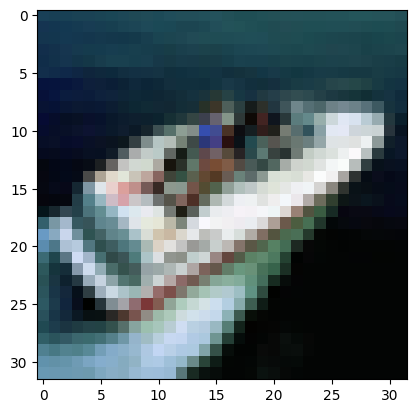

In [ ]:
print(test_DS.classes)
print(test_DS.class_to_idx)
x_batch, y_batch = next(iter(train_DL)) # 데이터 한국자 뜨기
print(x_batch.shape)
# [32, 3, 32, 32]라서 좀 헷갈릴 수 있는데 배치 사이즈가 앞의 32, 그 뒤 3이 RGB, 32x32는 픽셀임

plt.imshow(x_batch[0].permute(1,2,0))
print(test_DS.classes[y_batch[0]])

In [ ]:
print(type(train_DS.data))
print(train_DS.data.shape)
print(train_DS.data.dtype)
print(train_DS.data[0][0][0][0])


x_batch, y_batch = next(iter(train_DL)) # 데이터 한 국자 # next(iter(train_DS)) 는 한장만 꺼내기

# ToTensor 의 역할
# 1. tensor 로 바꾸고
# 2. 개채행열로 바꾸고
# 3. 0~1 사이로 바꾸고 (int -> float)
print(type(x_batch))
print(x_batch.shape)
print(x_batch.dtype)
print(x_batch[0][0][0][0]) # 0~1 사이의 값이 나옴

<class 'numpy.ndarray'>
(50000, 32, 32, 3)
uint8
59
<class 'torch.Tensor'>
torch.Size([32, 3, 32, 32])
torch.float32
tensor(0.2902)


- 위에 `model_type` 변수를 바꿔 원하는 모델(만든 클래스)을 불러오자.

In [ ]:
# MLP
class MLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.linear = nn.Sequential(nn.Linear(3*32*32, 30),
                                    nn.BatchNorm1d(30),
                                    nn.ReLU(),
                                    nn.Linear(30, 10))
    def forward(self,x):
        x = torch.flatten(x, start_dim=1)
        x = self.linear(x)
        return x

class MLP_shallow(nn.Module): # 내 필기용
    def __init__(self):
        super().__init__()
        self.linear = nn.Sequential(nn.Linear(3*32*32, 100),
                                    nn.BatchNorm1d(100),
                                    nn.ReLU(),
                                    nn.Linear(100, 10))
    def forward(self,x):
        x = torch.flatten(x, start_dim=1)
        x = self.linear(x)
        return x

class MLP_deep(nn.Module): # 내 필기용
    def __init__(self):
        super().__init__()
        self.linear = nn.Sequential(nn.Linear(3*32*32, 75),
                                    nn.BatchNorm1d(75),
                                    nn.ReLU(),
                                    *[i for _ in range(13) for i in [nn.Linear(75, 75),nn.BatchNorm1d(75),nn.ReLU()]],
                                    nn.Linear(75, 10))
    def forward(self,x):
        x = torch.flatten(x, start_dim=1)
        x = self.linear(x)
        return x

# CNN
class CNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Sequential(nn.Conv2d(3,8,3, padding=1),
                                   nn.BatchNorm2d(8),
                                   nn.ReLU())
        self.Maxpool1 = nn.MaxPool2d(2)
        self.conv2 = nn.Sequential(nn.Conv2d(8,16,3, padding=1),
                                   nn.BatchNorm2d(16),
                                   nn.ReLU())
        self.Maxpool2 = nn.MaxPool2d(2)
        self.conv3 = nn.Sequential(nn.Conv2d(16,32,3, padding=1),
                                   nn.BatchNorm2d(32),
                                   nn.ReLU())
        self.Maxpool3 = nn.MaxPool2d(2)
        self.fc = nn.Linear(32*4*4,10)

    def forward(self, x):
        x = self.conv1(x)
        x = self.Maxpool1(x)
        x = self.conv2(x)
        x = self.Maxpool2(x)
        x = self.conv3(x)
        x = self.Maxpool3(x)
        x = torch.flatten(x, start_dim=1)
        x = self.fc(x)
        return x

class CNN_deep(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv_block1 = nn.Sequential(nn.Conv2d(3,32,3,padding=1),
                                         nn.BatchNorm2d(32),
                                         nn.ReLU(),
                                         nn.Conv2d(32,32,3,padding=1),
                                         nn.BatchNorm2d(32),
                                         nn.ReLU())
        self.Maxpool1 = nn.MaxPool2d(2)

        # 풀링으로 크기를 줄였는데.. 왜 32로 유지되지? <- 줄어든게 맞는데 32는 피쳐맵 수지 그 크기는 아님. 크기는 분명히 작아졌음 ㅇㅇ.
        self.conv_block2 = nn.Sequential(nn.Conv2d(32,64,3,padding=1),
                                         nn.BatchNorm2d(64),
                                         nn.ReLU(),
                                         nn.Conv2d(64,64,3,padding=1),
                                         nn.BatchNorm2d(64),
                                         nn.ReLU(),
                                         nn.Conv2d(64,64,3,padding=1),
                                         nn.BatchNorm2d(64),
                                         nn.ReLU())
        self.Maxpool2 = nn.MaxPool2d(2)

        self.conv_block3 = nn.Sequential(nn.Conv2d(64,128,3,padding=1),
                                         nn.BatchNorm2d(128),
                                         nn.ReLU(),
                                         nn.Conv2d(128,128,3,padding=1),
                                         nn.BatchNorm2d(128),
                                         nn.ReLU(),
                                         nn.Conv2d(128,128,3,padding=1),
                                         nn.BatchNorm2d(128),
                                         nn.ReLU())
        self.Maxpool3 = nn.MaxPool2d(2)

        self.classifier = nn.Sequential(nn.Linear(128*4*4,512),
                                        nn.ReLU(),
                                        nn.Linear(512,10))

    def forward(self, x):
        x = self.conv_block1(x)
        x = self.Maxpool1(x)
        x = self.conv_block2(x)
        x = self.Maxpool2(x)
        x = self.conv_block3(x)
        x = self.Maxpool3(x)
        x = torch.flatten(x, start_dim=1)
        x = self.classifier(x)
        return x

In [ ]:
model = globals()[model_type]().to(DEVICE)
print(model)

x_batch, _ = next(iter(train_DL))
print(x_batch.shape)

model.eval()
with torch.no_grad():
    print(model(x_batch.to(DEVICE)).shape)

MLP_deep(
  (linear): Sequential(
    (0): Linear(in_features=3072, out_features=75, bias=True)
    (1): BatchNorm1d(75, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Linear(in_features=75, out_features=75, bias=True)
    (4): BatchNorm1d(75, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU()
    (6): Linear(in_features=75, out_features=75, bias=True)
    (7): BatchNorm1d(75, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (8): ReLU()
    (9): Linear(in_features=75, out_features=75, bias=True)
    (10): BatchNorm1d(75, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (11): ReLU()
    (12): Linear(in_features=75, out_features=75, bias=True)
    (13): BatchNorm1d(75, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (14): ReLU()
    (15): Linear(in_features=75, out_features=75, bias=True)
    (16): BatchNorm1d(75, eps=1e-05, momentum=0.1, affine=True, track_run

- 꽤 걸림

Epoch: 1, train loss: 1.933
--------------------
Epoch: 2, train loss: 1.737
--------------------
Epoch: 3, train loss: 1.655
--------------------
Epoch: 4, train loss: 1.594
--------------------
Epoch: 5, train loss: 1.549
--------------------
Epoch: 6, train loss: 1.506
--------------------
Epoch: 7, train loss: 1.468
--------------------
Epoch: 8, train loss: 1.442
--------------------
Epoch: 9, train loss: 1.409
--------------------
Epoch: 10, train loss: 1.383
--------------------


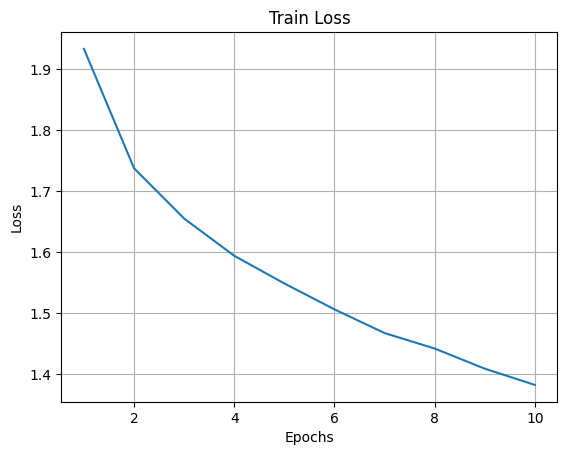

In [ ]:
if new_model_train:
    optimizer = optim.Adam(model.parameters(), lr = LR)

    loss_history = Train(model, train_DL, criterion, optimizer, EPOCH)

    torch.save(model, save_model_path)

    plt.figure()
    plt.plot(range(1,EPOCH+1),loss_history)
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.title("Train Loss")
    plt.grid()

In [ ]:
load_model = torch.load(save_model_path, map_location=DEVICE, weights_only=False)

In [ ]:
Test(load_model, test_DL)
print("파라미터 개수: ", count_params(load_model))

Test accuracy: 4985/10000 (49.9 %)
파라미터 개수:  307435


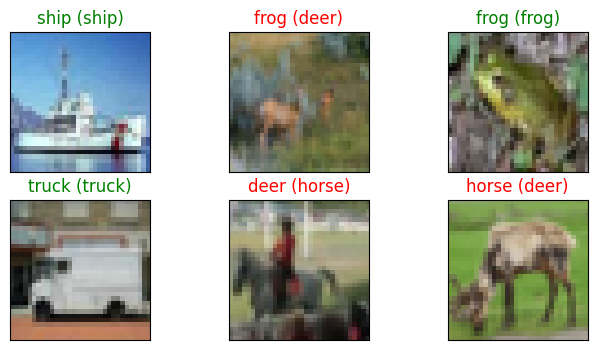

In [ ]:
Test_plot(load_model,test_DL)

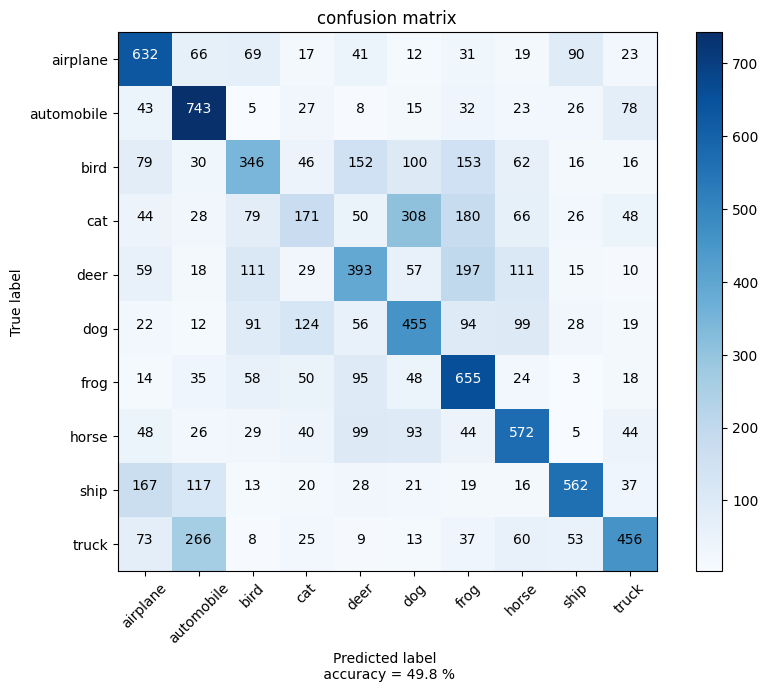

In [ ]:
confusion = get_conf(load_model, test_DL)
plot_confusion_matrix(confusion, test_DS.classes)
plt.xticks(rotation=45);

- 고양이랑 개 구분을 힘들어하는구먼

5에포크 기준

- 그냥 MLP 2층: 47%, 파라미터 9만개

- MLP deep: 45.8%, 파라미터 30만개 <- 근데 이건 아마 epoch가 낮아서 그럴 듯? <- 근데 10에포크 돌려도 겨우 50퍼임.

- CNN 얕게: 64%, 파라미터 만개

- CNN deep: 77.6%, 파라미터 15만개 (10 에포크 기준 81%)

- MLP 보다 **CNN이 파라미터가 더 적어도** 보통 성능이 여기서 훨씬 **좋음**.